En esta actividad trabajaremos con una base de datos recuperada en el semestre de Otoño 2022
en una clase de Sistemas Digitales en la Universidad de Monterrey. En dicha materia, cada
semana se entregan actividades y la bandeja de entrega se cierra cada domingo a medianoche.
intentaremos confirmar o rechazar la  hipótesis de que entre más cerca de la hora
de cierre de la bandeja se entrega la tarea, peor la calificación en la misma. 

Utilizaremos el archivo de nombre “A1.6 Tiempo de Entrega.csv”, donde podremos encontrar
información para 432 actividades entregadas, organizadas de la siguiente manera:

“Tiempo”. Tiempo restante para que se cerrara la bandeja, en horas. Es decir, un 1 indica
que entregaron la actividad el domingo a las 11:00 p.m., y un 48 indica que entregaron la
actividad 48 horas antes del domingo a medianoche.

“Calificacion”. Calificación obtenida, en una escala entre el 0 y el 110.

1. Generaresmos una gráfica de dispersión que muestre el comportamiento de los datos. Agregaremos una línea de
texto en la que generaremos una predicción sobre qué tipo de algoritmo será el más adecuado
para resolver la tarea.


In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm

# Cargar los datos
data = pd.read_csv("A1.6 Tiempo de Entrega.csv")
df.head()

,Tiempo,Calificacion
0,85.076389,85.0
1,84.675556,85.0
2,79.553889,110.0
3,75.310556,110.0
4,64.958611,110.0


In [156]:
# Asegurar que los datos sean numéricos
data['Tiempo'] = pd.to_numeric(data['Tiempo'], errors='coerce')
data['Calificacion'] = pd.to_numeric(data['Calificacion'], errors='coerce')

# Eliminamos las filas con valores faltantes
data = data.dropna()

# Eliminación de valores atípicos utilizando cuartiles (IQR)
Q1 = data[['Tiempo', 'Calificacion']].quantile(0.25)
Q3 = data[['Tiempo', 'Calificacion']].quantile(0.75)
IQR = Q3 - Q1

# Filtrar los datos que no están fuera del rango intercuartílico
data_cleaned = data[~((data[['Tiempo', 'Calificacion']] < (Q1 - 1.5 * IQR)) | (data[['Tiempo', 'Calificacion']] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Ver los datos después de la limpieza
print(f"Datos antes de la limpieza: {len(data)}")
print(f"Datos después de la limpieza: {len(data_cleaned)}")


Datos antes de la limpieza: 428
Datos después de la limpieza: 332


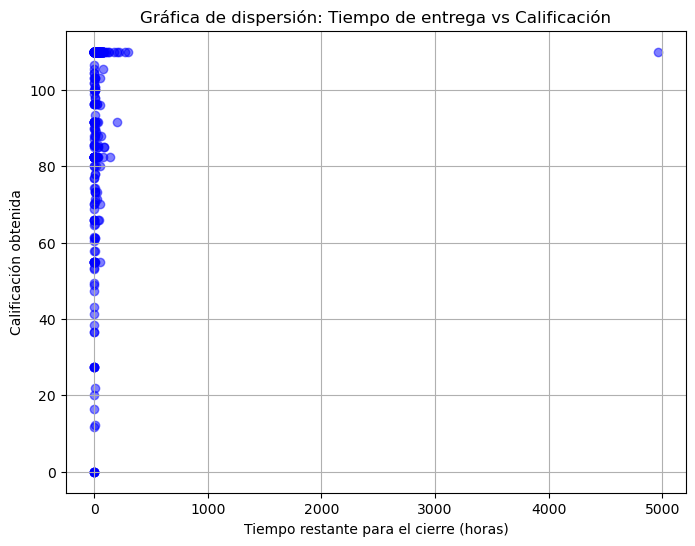

In [154]:
# Graficar los datos
plt.figure(figsize=(8,6))
plt.scatter(df['Tiempo'], df['Calificacion'], color='blue', alpha=0.5)
plt.title('Gráfica de dispersión: Tiempo de entrega vs Calificación')
plt.xlabel('Tiempo restante para el cierre (horas)')
plt.ylabel('Calificación obtenida')
plt.grid(True)
plt.show()


Es claro que entre mis datos tenemos valores atípicos, y metiéndonos en la base de datos nos percatamos de que no hay huecos, por lo tanto atacaremos a los valores que se pueden considerar errores.


In [168]:
import numpy as np

#Eliminar los valores atípicos utilizando rango intercuartíl.
Q1_tiempo = df['Tiempo'].quantile(0.25)
Q3_tiempo = df['Tiempo'].quantile(0.75)
IQR_tiempo = Q3_tiempo - Q1_tiempo

Q1_calificacion = df['Calificacion'].quantile(0.25)
Q3_calificacion = df['Calificacion'].quantile(0.75)
IQR_calificacion = Q3_calificacion - Q1_calificacion
limite_inferior_tiempo = Q1_tiempo - 1.5 * IQR_tiempo
limite_superior_tiempo = Q3_tiempo + 1.5 * IQR_tiempo
limite_inferior_calificacion = Q1_calificacion - 1.5 * IQR_calificacion
limite_superior_calificacion = Q3_calificacion + 1.5 * IQR_calificacion

# Filtrar eliminando valores atípicos
df_filtrado = df[(df['Tiempo'] >= limite_inferior_tiempo) & (df['Tiempo'] <= limite_superior_tiempo)]
df_filtrado = df_filtrado[(df_filtrado['Calificacion'] >= limite_inferior_calificacion) & (df_filtrado['Calificacion'] <= limite_superior_calificacion)]

df_filtrado.head()


,Tiempo,Calificacion
13,31.353333,85.0
14,9.126667,103.0
15,8.795833,110.0
16,8.664444,78.0
17,7.531389,78.0


Graficamos nuevamente

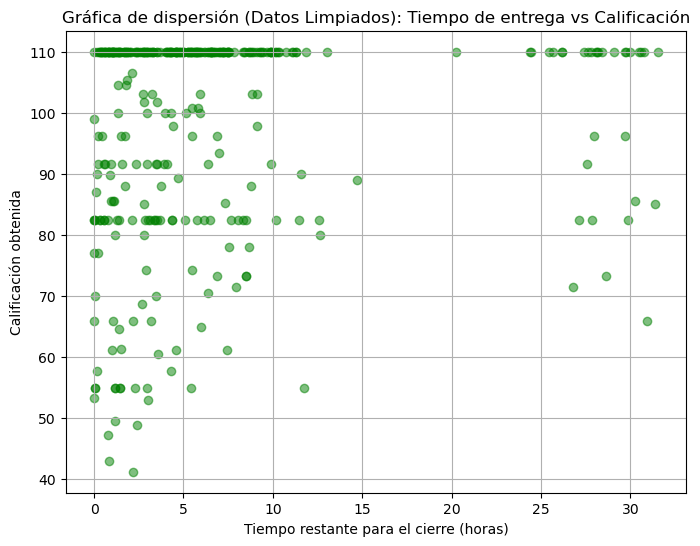

In [170]:
plt.figure(figsize=(8,6))
plt.scatter(df_filtrado['Tiempo'], df_filtrado['Calificacion'], color='green', alpha=0.5)
plt.title('Gráfica de dispersión (Datos Limpiados): Tiempo de entrega vs Calificación')
plt.xlabel('Tiempo restante para el cierre (horas)')
plt.ylabel('Calificación obtenida')
plt.grid(True)
plt.show()


2. Separaremos los datos en entrenamiento y prueba, con una relación de 70/30. Imprimiremos en
consola el promedio de los tiempos en el conjunto de entrenamiento y en el conjunto de
prueba, posteriormente también con las calificaciónes.

In [172]:
from sklearn.model_selection import train_test_split

# Separar los datos 70/30
X = df_filtrado[['Tiempo']]  
y = df_filtrado['Calificacion']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

# Promedios para el conjunto de entrenamiento
promedio_tiempo_train = X_train['Tiempo'].mean()
promedio_calificacion_train = y_train.mean()

# romedios para el conjunto de prueba
promedio_tiempo_test = X_test['Tiempo'].mean()
promedio_calificacion_test = y_test.mean()

# Imprimimos resultados
print(f"Promedio de tiempo en el conjunto de entrenamiento: {promedio_tiempo_train:.2f} horas")
print(f"Promedio de calificación en el conjunto de entrenamiento: {promedio_calificacion_train:.2f}")
print(f"Promedio de tiempo en el conjunto de prueba: {promedio_tiempo_test:.2f} horas")
print(f"Promedio de calificación en el conjunto de prueba: {promedio_calificacion_test:.2f}")


Promedio de tiempo en el conjunto de entrenamiento: 6.50 horas
Promedio de calificación en el conjunto de entrenamiento: 97.60
Promedio de tiempo en el conjunto de prueba: 7.13 horas
Promedio de calificación en el conjunto de prueba: 97.30


En este caso que los promedios de tiempo y calificación en el conjunto de entrenamiento y prueba son similares podemos confiar en que la distribución de los datos es consistente entre ambos conjuntos. Y esto lo hace adecuado para correr un modelo con un poco más de seguridad en mis tados.


3. Entrenaremos un modelo de regresión polinomial usando los datos de entrenamiento. Imprimiremos un resumen de los resultados obtenidos y agrega una línea de texto en la que comentaremos sobre el tipo de
relación (positiva o negativa; ¿a menor tiempo menor calificación?) entre el término lineal
y la respuesta, lo que esto significa y si dicha variable está significativamente asociada
con las calificaciones.


                            OLS Regression Results                            
Dep. Variable:           Calificacion   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     6.685
Date:                Wed, 12 Feb 2025   Prob (F-statistic):            0.00151
Time:                        11:54:20   Log-Likelihood:                -978.02
No. Observations:                 232   AIC:                             1962.
Df Residuals:                     229   BIC:                             1972.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         92.9279      1.993     46.625      0.0

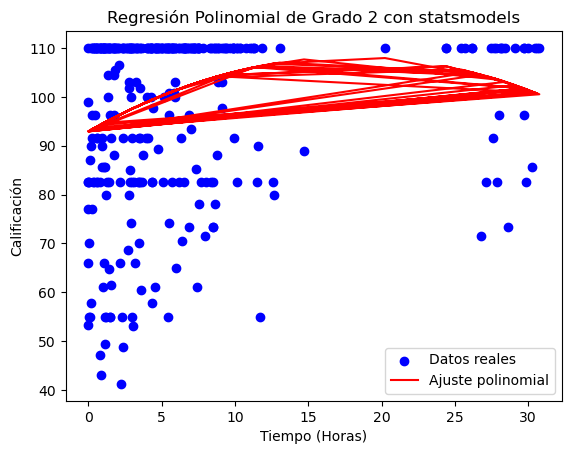

In [174]:
# Variables
X = data_cleaned[['Tiempo']]  # Variable independiente (Tiempo)
y = data_cleaned['Calificacion']  # Variable dependiente (Calificación)

# División de los datos en entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear un modelo de regresión polinomial de grado 2
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)

# Convertimos el DataFrame de X_poly_train en una estructura compatible con statsmodels
X_poly_train_sm = sm.add_constant(X_poly_train)  # Agregamos la constante (intersección)

# Creamos el modelo OLS (Ordinary Least Squares)
model = sm.OLS(y_train, X_poly_train_sm)
results = model.fit()

# Imprimimos el resumen de los resultados
print(results.summary())

# Hacemos predicciones
X_poly_test = poly.transform(X_test)
X_poly_test_sm = sm.add_constant(X_poly_test)
y_pred = results.predict(X_poly_test_sm)

# Evaluación del modelo
mse = ((y_test - y_pred) ** 2).mean()
print(f"Error cuadrático medio (MSE): {mse}")

# Gráfica de la regresión polinomial
plt.scatter(X, y, color='blue', label='Datos reales')
plt.plot(X, results.predict(sm.add_constant(poly.fit_transform(X))), color='red', label='Ajuste polinomial')
plt.xlabel('Tiempo (Horas)')
plt.ylabel('Calificación')
plt.title('Regresión Polinomial de Grado 2 con statsmodels')
plt.legend()
plt.show()



El coeficiente de Tiempo (x1) es positivo (1.6918),esto nos indica que a mayor tiempo de entrega, mayor calificación. Por lo tanto, los estudiantes que entregan sus tareas más tarde tienden a obtener mejores calificaciones, pero esta relación no es completamente lineal.

El coeficiente de Tiempo^2 (x2) es negativo (-0.0470), lo que sugiere que la relación es parabólica. Aunque los estudiantes que entregan más tarde en general obtienen mejores calificaciones, este efecto se reduce a medida que el tiempo de entrega se alarga demasiado. Después de un cierto punto, entregar tareas más tarde puede dejar de ser beneficioso y empezar a afectar la calificación.

El R-squared es bajo con un 0.055 lo que indica que el modelo no está capturando bien la dispersión de las calificaciones solo con el tiempo de entrega. Estamos limitados de datos.

4. Entrenaremos un modelo de regresión segmentada, utilizando regresiones cuadráticas para cada segmento. Generaremos estimaciones en los datos de validación. 

Error cuadrático medio (MSE): 381.7570711400496


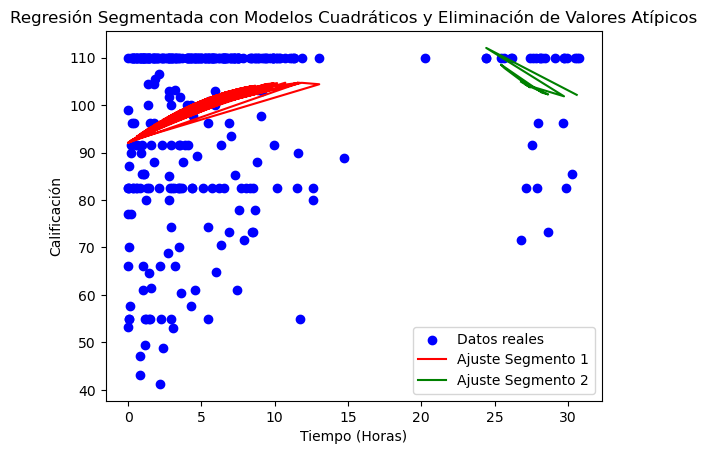

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

data = pd.read_csv("A1.6 Tiempo de Entrega.csv")
data['Tiempo'] = pd.to_numeric(data['Tiempo'], errors='coerce')
data['Calificacion'] = pd.to_numeric(data['Calificacion'], errors='coerce')
data = data.dropna()
Q1 = data[['Tiempo', 'Calificacion']].quantile(0.25)
Q3 = data[['Tiempo', 'Calificacion']].quantile(0.75)
IQR = Q3 - Q1
data_clean = data[~((data[['Tiempo', 'Calificacion']] < (Q1 - 1.5 * IQR)) | (data[['Tiempo', 'Calificacion']] > (Q3 + 1.5 * IQR))).any(axis=1)]

X = data_clean[['Tiempo']]  # Variable independiente (Tiempo)
y = data_clean['Calificacion']  # Variable dependiente (Calificación)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Definir el umbral para la segmentación (por ejemplo, Tiempo = 24)
threshold = 24

# Dividir los datos en dos segmentos
X_train_segment_1 = X_train[X_train['Tiempo'] <= threshold]
y_train_segment_1 = y_train[X_train['Tiempo'] <= threshold]

X_train_segment_2 = X_train[X_train['Tiempo'] > threshold]
y_train_segment_2 = y_train[X_train['Tiempo'] > threshold]

# Crear y entrenar los modelos cuadráticos para cada segmento
poly = PolynomialFeatures(degree=2)

# Segmento 1
X_poly_segment_1 = poly.fit_transform(X_train_segment_1)
model_1 = LinearRegression()
model_1.fit(X_poly_segment_1, y_train_segment_1)

# Segmento 2
X_poly_segment_2 = poly.fit_transform(X_train_segment_2)
model_2 = LinearRegression()
model_2.fit(X_poly_segment_2, y_train_segment_2)

# Realizar predicciones
X_poly_test_segment_1 = poly.transform(X_test[X_test['Tiempo'] <= threshold])
X_poly_test_segment_2 = poly.transform(X_test[X_test['Tiempo'] > threshold])

y_pred_segment_1 = model_1.predict(X_poly_test_segment_1)
y_pred_segment_2 = model_2.predict(X_poly_test_segment_2)

# Unir las predicciones
y_pred = np.concatenate([y_pred_segment_1, y_pred_segment_2])

# Evaluación del modelo
mse = ((y_test - y_pred) ** 2).mean()
print(f"Error cuadrático medio (MSE): {mse}")

# Graficamos los resultados
plt.scatter(X, y, color='blue', label='Datos reales')

# Dibujamos las predicciones de cada segmento
plt.plot(X_test[X_test['Tiempo'] <= threshold], y_pred_segment_1, color='red', label='Ajuste Segmento 1')
plt.plot(X_test[X_test['Tiempo'] > threshold], y_pred_segment_2, color='green', label='Ajuste Segmento 2')

plt.xlabel('Tiempo (Horas)')
plt.ylabel('Calificación')
plt.title('Regresión Segmentada con Modelos Cuadráticos y Eliminación de Valores Atípicos')
plt.legend()
plt.show()


5. Entrenaremos un modelo KNN para regresión investiganof el valor de k que sea más adecuado. Generaremos estimaciones en los datos de validación.

Valor de k: 1, MSE: 582.8501
Valor de k: 3, MSE: 423.8370
Valor de k: 5, MSE: 360.6264
Valor de k: 7, MSE: 322.3504
Valor de k: 9, MSE: 313.7023
Valor de k: 11, MSE: 333.5497

El mejor valor de k es: 9
Error cuadrático medio (MSE) con el mejor k (9): 313.7023


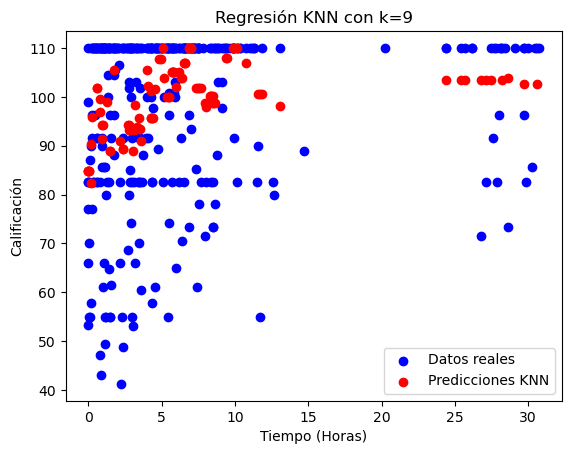

In [230]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Normalizar los datos para KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo KNN para diferentes valores de k
k_values = [1, 3, 5, 7, 9, 11]  # Probamos con diferentes valores de k
mse_values = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)
    print(f'Valor de k: {k}, MSE: {mse:.4f}')

# Seleccionamos el valor de k que minimiza el MSE
best_k = k_values[np.argmin(mse_values)]
print(f'\nEl mejor valor de k es: {best_k}')

# Entrenamos el modelo con el mejor k
best_knn = KNeighborsRegressor(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

# Hacemos las predicciones con el modelo entrenado
y_pred_best_knn = best_knn.predict(X_test_scaled)

# Evaluación final del modelo
final_mse = mean_squared_error(y_test, y_pred_best_knn)
print(f'Error cuadrático medio (MSE) con el mejor k ({best_k}): {final_mse:.4f}')


plt.scatter(X, y, color='blue', label='Datos reales')
plt.scatter(X_test, y_pred_best_knn, color='red', label='Predicciones KNN')
plt.xlabel('Tiempo (Horas)')
plt.ylabel('Calificación')
plt.title(f'Regresión KNN con k={best_k}')
plt.legend()
plt.show()


6. Calcula el RSE en los datos de prueba para los 3 modelos y agrega una línea de texto
donde comentes sobre sus diferencias y si hay un claro “ganador”. No te bases
exclusivamente en el error, puedes considerar también aspectos como la interpretabilidad
del modelo.

7. Para los datos de prueba, graficaremos tanto las calificaciones reales como las predichas por
los 3 modelos en un mismo plot, asegurándonos de utilizar etiquetas, colores y/o distintos
marcadores para diferenciar y describir a cada modelo.

RSE Modelo 1 (Polinomial con statsmodels): 19.0473
RSE Modelo 2 (Segmentado con cuadráticas): 19.8384
RSE Modelo 3 (KNN): 19.0858

Comparativa de los modelos:
El Modelo 1 (Polinomial con statsmodels) tiene el mejor RSE.


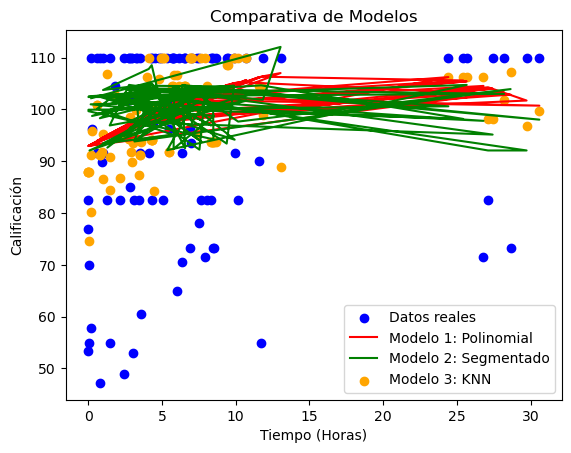

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

# Modelo 1: Regresión Polinomial con statsmodels
# Asumimos que los datos ya están cargados y limpiados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_train_sm = sm.add_constant(X_poly_train)

model = sm.OLS(y_train, X_poly_train_sm)
results = model.fit()

X_poly_test = poly.transform(X_test)
X_poly_test_sm = sm.add_constant(X_poly_test)
y_pred_model_1 = results.predict(X_poly_test_sm)

# Calcular RSE para el Modelo 1
residuals_model_1 = y_test - y_pred_model_1
rse_model_1 = np.sqrt(np.sum(residuals_model_1**2) / (len(y_test) - len(results.params)))

print(f"RSE Modelo 1 (Polinomial con statsmodels): {rse_model_1:.4f}")


# Modelo 2: Regresión Segmentada con Modelos Cuadráticos
# Suponiendo que X_train_segment_1, y_train_segment_1, X_train_segment_2, y_train_segment_2 ya están definidos

threshold = 24
X_poly_test_segment_1 = poly.transform(X_test[X_test['Tiempo'] <= threshold])
X_poly_test_segment_2 = poly.transform(X_test[X_test['Tiempo'] > threshold])

y_pred_segment_1 = model_1.predict(X_poly_test_segment_1)
y_pred_segment_2 = model_2.predict(X_poly_test_segment_2)
y_pred_model_2 = np.concatenate([y_pred_segment_1, y_pred_segment_2])

# Calcular RSE para el Modelo 2
residuals_model_2 = y_test - y_pred_model_2
rse_model_2 = np.sqrt(np.sum(residuals_model_2**2) / (len(y_test) - 3))  # Ajuste debido a 3 parámetros en total

print(f"RSE Modelo 2 (Segmentado con cuadráticas): {rse_model_2:.4f}")


# Modelo 3: KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_knn = KNeighborsRegressor(n_neighbors=5)  # Usando el mejor k encontrado antes
best_knn.fit(X_train_scaled, y_train)

y_pred_model_3 = best_knn.predict(X_test_scaled)

# Calcular RSE para el Modelo 3
residuals_model_3 = y_test - y_pred_model_3
rse_model_3 = np.sqrt(np.sum(residuals_model_3**2) / (len(y_test) - best_knn.n_features_in_))

print(f"RSE Modelo 3 (KNN): {rse_model_3:.4f}")

# Comparativa final
print("\nComparativa de los modelos:")
if rse_model_1 < rse_model_2 and rse_model_1 < rse_model_3:
    print("El Modelo 1 (Polinomial con statsmodels) tiene el mejor RSE.")
elif rse_model_2 < rse_model_1 and rse_model_2 < rse_model_3:
    print("El Modelo 2 (Segmentado con cuadráticas) tiene el mejor RSE.")
else:
    print("El Modelo 3 (KNN) tiene el mejor RSE.")

# Graficar los resultados
plt.scatter(X_test, y_test, color='blue', label='Datos reales')

# Gráficas de los modelos
plt.plot(X_test, y_pred_model_1, color='red', label='Modelo 1: Polinomial')
plt.plot(X_test, y_pred_model_2, color='green', label='Modelo 2: Segmentado')
plt.scatter(X_test, y_pred_model_3, color='orange', label='Modelo 3: KNN')

plt.xlabel('Tiempo (Horas)')
plt.ylabel('Calificación')
plt.title('Comparativa de Modelos')
plt.legend()
plt.show()


A pesar el Modelo 1 tiene el mejor RSE, lo que sugiere que es el modelo más preciso, la decisión final sobre qué modelo usar también debería considerar la interpretabilidad y la flexibilidad del modelo en relación con el problema. Si la interpretabilidad es fundamental, el Modelo 1 es una opción sólida, pero si la flexibilidad y la capacidad de adaptación a diferentes patrones son más importantes, el Modelo 3 podría ser una opción adecuada. En estre caso que se necesita objetividad y no hay tanto espacio para la flexibilida, optaremos por quedarnos con el Modelo 1.